# TU060 - 

#### Student: Eamonn Kelly - student #: D24127620

#### Assignment - Text Mining


## Step 1 . Data Understanding and Preparation (20 points)

### 1.1 Problem Definition:

Identify feedback that we can integrate into our McDonalds business decision making process, which can have a direct business impact. 

<u>Question</u>: Can we identify Negative feedback which can be used to improve services and offerings, and also Identify Positive feedback on products and services to enhance offerings and provide more targeted use of marketing budget.


In [1]:
import pandas as pd
import numpy as np
import csv
from nltk.tokenize import sent_tokenize, word_tokenize, RegexpTokenizer
import nltk
from urllib.request import urlopen
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
from collections import defaultdict
from pathlib import Path
from ydata_profiling import ProfileReport

import matplotlib.pyplot as plt

import io 
import re
import os
import json
import seaborn as sns
from io import StringIO
from pprint import pprint
from datetime import datetime, timedelta
# from pdfminer.converter import TextConverter
# from pdfminer.pdfinterp import PDFPageInterpreter
# #from pdfminer.ptest_test_df1st_df11interp import PDFResourceManager
# from pdfminer.pdfpage import PDFPage
# from pdfminer.layout import LAParams
# from pdfminer.high_level import extract_text
# from pdfminer.pdfdocument import PDFDocument

from nltk.stem import WordNetLemmatizer

from sklearn.datasets import load_files

### 1.2 Data Preparation

1.2a Import data set and analyse structure

In [4]:
#defining global variable path to files and data, it is called thropughout modify this path to match your local path
path = './'

Import csv

McDoalds review dataset was downloaded from Kaggle - https://www.kaggle.com/datasets/nelgiriyewithana/mcdonalds-store-review


In [5]:
# csv was downlaoded from url above an the imported using read_csv here
mcd_df = pd.read_csv(os.path.join(path, 'McDonald_s_Reviews.csv'), encoding="ISO-8859-1")

mcd_df.head(20)

,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
0,1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,Why does it look like someone spit on my food?...,1 star
1,2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,It'd McDonalds. It is what it is as far as the...,4 stars
2,3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,Made a mobile order got to the speaker and che...,1 star
3,4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",a month ago,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5 stars
4,5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",2 months ago,"I repeat my order 3 times in the drive thru, a...",1 star
5,6,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 weeks ago,I work for door dash and they locked us all ou...,1 star
6,7,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,If I could give this location a zero on custo...,1 star
7,8,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",a year ago,Came in and ordered a Large coffee w/no ice. T...,1 star
8,9,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,Went thru drive thru. Ordered. Getting home no...,1 star
9,10,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,"I'm not really a huge fan of fast food, but I ...",4 stars


Get the dtypes per column

In [6]:
print(mcd_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33396 entries, 0 to 33395
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   reviewer_id    33396 non-null  int64  
 1   store_name     33396 non-null  object 
 2   category       33396 non-null  object 
 3   store_address  33396 non-null  object 
 4   latitude       32736 non-null  float64
 5   longitude      32736 non-null  float64
 6   rating_count   33396 non-null  object 
 7   review_time    33396 non-null  object 
 8   review         33396 non-null  object 
 9   rating         33396 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 2.5+ MB
None


Get stats on numerical data in the data set

In [7]:
print(mcd_df.describe())

        reviewer_id     latitude      longitude
count  33396.000000  32736.000000  32736.000000
mean   16698.500000     34.442546    -90.647033
std     9640.739131      5.344116     16.594844
min        1.000000     25.790295   -121.995421
25%     8349.750000     28.655350    -97.792874
50%    16698.500000     33.931261    -81.471414
75%    25047.250000     40.727401    -75.399919
max    33396.000000     44.981410    -73.459820


Assess general cleanliness of data, missing values, duplicates, rogue characters etc

In [8]:
# quick look at data to see if its clean, no duplicates, null values unusual characters etc
# convert it to d first so can easily run some checks over it
# mcd_df=pd.DataFrame(processed_per_file_data)
# view various dataframe details
# checking for null values and specific unknown values
print ("Rows     : " , mcd_df.shape[0])
print ("Columns  : " , mcd_df.shape[1])
print('------')
print ("\nFeatures : \n" , mcd_df.columns.tolist())
print('------')
print ("\nMissing values :  ", mcd_df.isnull().sum().values.sum())
print('------')
print ("\nMissing values per column:  ", mcd_df.isnull().sum())
print('------')
print('\nnum of dups in df   =   {}'.format(mcd_df.duplicated().sum()))
print('------')
print ("\nUnique values :  \n", mcd_df.nunique())
print('------')
print('\n null values = ', mcd_df.isnull().values.any())
print('------')
mcd_df_missing = (mcd_df=='?').sum()
print('\"  ?   \" values present =  \n',mcd_df_missing)
print('------')
mcd_df_unknown = (mcd_df=='unknown').sum()
print('\"   unknown   \" values present =  \n',mcd_df_unknown)
print('------')
mcd_df_na = mcd_df.isin(['N/A', 'N\\A', 'NA', 'n/a', 'n\\A', 'na', 'N_A']).sum()
print('    NA     values present = \n', mcd_df_na)
print('------')
mcd_df_none = mcd_df.isin(['None', 'none']).sum()
print('    none    values present = \n', mcd_df_none)
print('------')
# regex https://stackoverflow.com/questions/2124010/grep-regex-to-match-non-ascii-characters
# count of rows per column containing non-ascii characters
rogue_ascii_df = mcd_df.apply(lambda s: s.astype(str).str.contains(r"[^\x00-\x7F]", regex=True, na=False).sum())
print("    non ascii chars   values present:\n", rogue_ascii_df)

Rows     :  33396
Columns  :  10
------

Features : 
 ['reviewer_id', 'store_name', 'category', 'store_address', 'latitude ', 'longitude', 'rating_count', 'review_time', 'review', 'rating']
------

Missing values :   1320
------

Missing values per column:   reviewer_id        0
store_name         0
category           0
store_address      0
latitude         660
longitude        660
rating_count       0
review_time        0
review             0
rating             0
dtype: int64
------

num of dups in df   =   0
------

Unique values :  
 reviewer_id      33396
store_name           2
category             1
store_address       40
latitude            39
longitude           39
rating_count        51
review_time         39
review           22285
rating               5
dtype: int64
------

 null values =  True
------
"  ?   " values present =  
 reviewer_id      0
store_name       0
category         0
store_address    0
latitude         0
longitude        0
rating_count     0
review_time     

Check the non ascii characters int he flagged columns from earlier

In [10]:
# get list of columns contianing no ascii characters - convert ti to a list to sue later
ascii_cols = rogue_ascii_df[rogue_ascii_df > 0].index.tolist()


for col_name in ascii_cols:
    print(f" =========== {col_name} ==================")
    # create a boolean mask series , ensure dtype is str, if str contains anythgi outsid eof ascii range if missing values allocate as not macthing
    mask = mcd_df[col_name].astype(str).str.contains(r"[^\x00-\x7F]", regex=True, na=False )
    
    # view the numebr of rows affected and then the actual non ascii row, only once tho
    print(f" number of rows with non ascii  =  {mask.sum()}")
    print(mcd_df.loc[mask, col_name].drop_duplicates().head(20))





 =========== store_name ==================
 number of rows with non ascii  =  71
500    ýýýMcDonald's
Name: store_name, dtype: object
 =========== store_address ==================
 number of rows with non ascii  =  660
22141    2476 Kalï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿...
Name: store_address, dtype: object
 =========== review ==================
 number of rows with non ascii  =  3037
2     Made a mobile order got to the speaker and che...
3     My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...
7     Came in and ordered a Large coffee w/no ice. T...
9     I'm not really a huge fan of fast food, but I ...
10    Worst McDonaldï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿...
18    I am not happy at all today I went and bought ...
24    Didnï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½...
25    McDonaldï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿...
27    Doesnï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿...
29    First and last time I go to this location. Loo...
34    We hit it off pretty good in the beginning

Inspect review data containing '?' character

In [75]:
# check occurence f '?' character in the dataframe
# crteate a boolean mask for cells which contain  '?' character , do on row level, ie. axis = 1
mask = mcd_df.eq("?").any(axis=1)

# display onyl the row where this occurs i.e apply the mask t the dataframe
mcd_df.loc[mask]


,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
19669,19670,McDonald's,Fast food restaurant,"621 Broadway, Newark, NJ 07104, United States",40.77191,-74.161475,"1,564",6 years ago,?,2 stars


Check the unique values where there are low numbers of them to check to have a quick look

In [13]:
# view the unique values where there are lwo numbers of them to check to have a quick look
print("=================   store_name   =======================")
print(f" store_name values - count = {(mcd_df["store_name"].nunique())}")
print(f" store_name values = {(mcd_df["store_name"].unique())}")


print("=================   category  =======================")
print(f" category values - count = {(mcd_df['category'].nunique())}")
print(f" category values = {(mcd_df['category'].unique())}")


print("=================   rating  =======================")
print(f" rating values - count = {(mcd_df['rating'].nunique())}")
print(f" rating values = {(mcd_df['rating'].unique())}")


print("=================   review_time  =======================")
print(f" rating values - count = {(mcd_df['review_time'].nunique())}")
print(f" rating values = {(mcd_df['review_time'].unique())}")


print("=================   rating_count  =======================")
print(f" rating values = {(mcd_df['rating_count'].nunique())}")
print(f" rating values = {(mcd_df['rating_count'].unique())}")



=================   store_name   =======================
 store_name values - count = 2
 store_name values = ["McDonald's" "ýýýMcDonald's"]
=================   category  =======================
 category values - count = 1
 category values = ['Fast food restaurant']
=================   rating  =======================
 rating values - count = 5
 rating values = ['1 star' '4 stars' '5 stars' '2 stars' '3 stars']
=================   review_time  =======================
 rating values - count = 39
 rating values = ['3 months ago' '5 days ago' 'a month ago' '2 months ago' '3 weeks ago'
 'a year ago' '6 months ago' '5 months ago' '7 months ago' '10 months ago'
 '4 years ago' '8 months ago' '4 months ago' '3 years ago' '2 years ago'
 '9 months ago' '11 months ago' '5 years ago' '6 years ago' '7 years ago'
 '8 years ago' '3 days ago' 'a week ago' '2 days ago' '2 weeks ago'
 '10 years ago' '9 years ago' '6 days ago' '4 weeks ago' '21 hours ago'
 '4 days ago' '11 years ago' '12 years ago' 'a day

Get the number of unique 'rating_counts' per store

In [51]:
# this is a snaphsot of a count of reviews at a time when a  review was posted.
# won't get a lot of te proal data ouf it as max count for a store is two and min is one.... 
# may be useful to see which stores get reviewed the most and which don't  
print(mcd_df.groupby("store_address")["rating_count"].nunique())



store_address
1044 US-11, Champlain, NY 12919, United States                                2
10451 Santa Monica Blvd, Los Angeles, CA 90025, United States                 1
10901 Riverside Dr, North Hollywood, CA 91602, United States                  2
1100 N US Hwy 377, Roanoke, TX 76262, United States                           2
111 Madison St, Oak Park, IL 60302, United States                             1
1121 Garnet Ave, San Diego, CA 92109, United States                           1
11382 US-441, Orlando, FL 32837, United States                                1
114 Delancey St, New York, NY 10002, United States                            1
13749 US-183 Hwy, Austin, TX 78750, United States                             1
1415 E State Rd, Fern Park, FL 32730, United States                           2
151 West 34th Street (Macy's 7th Floor, New York, NY 10001, United States     1
1540 2nd St, Santa Monica, CA 90405, United States                            2
160 Broadway, New York, NY

Check to see of what class python object types are  i.e. str

In [15]:
# check to see actual python objhect types 
for col in mcd_df.select_dtypes(include="object").columns:
    print(col, mcd_df[col].map(type).value_counts())


store_name store_name
<class 'str'>    33396
Name: count, dtype: int64
category category
<class 'str'>    33396
Name: count, dtype: int64
store_address store_address
<class 'str'>    33396
Name: count, dtype: int64
rating_count rating_count
<class 'str'>    33396
Name: count, dtype: int64
review_time review_time
<class 'str'>    33396
Name: count, dtype: int64
review review
<class 'str'>    33396
Name: count, dtype: int64
rating rating
<class 'str'>    33396
Name: count, dtype: int64


Check to see if python 'object' columns contain alpha, numeric of mixture of both



In [21]:
# loop through the columns where type is object, we'll exclude int / float
for col in mcd_df.select_dtypes(include="object").columns:
    # loop through each column
    # check if row string contains digits using regex
    # digits anywhere in the text and if its nan label as no digits, True is one digit in a row int he column
    digits_present = mcd_df[col].str.contains(r"\d", na=False).any()
    print(f" {col} ---- contain digits and Text  - True/False = {digits_present}")


 store_name ---- contain digits and Text  - True/False = False
 category ---- contain digits and Text  - True/False = False
 store_address ---- contain digits and Text  - True/False = True
 rating_count ---- contain digits and Text  - True/False = True
 review_time ---- contain digits and Text  - True/False = True
 review ---- contain digits and Text  - True/False = True
 rating ---- contain digits and Text  - True/False = True


1.2b - Initial Data – Pre-Cleaning

- Data shape = (33,396, 10) > 33, 396 rows of data and 10 columns, parameter variables
    - Column analysis
        - 'reviewer_id'
            - dtype  = int  - numeric, unique ID, primary key
            - discrete data 
        - store_name
            - dtype = python object - str class - text, no variation in data.
            - categorical data
            - 71 rows with non ascii character present, same type for each row  =  ["McDonald's" "ýýýMcDonald's"]
            - we will fix this.
            - column data won't hold much value in later analysis work as contains no variation.
        - store_address
            - 'store_address' - dtype = python object - str class - alpha numeric, need to split out
            - categorical data
            - 1 non-ascii characters present - 
            - 660 rows with non ascii character,  same type for each row  = '2476 Kalï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿...''
            - will not modify as will address with 'store_id' solution
        - 'category'
            - dtype = python object - str class - text, no variation in data.
            - categorical data
            - of the type of restaurant
            - only 1 type,  ["Fast food restaurant"]
            - again, column won't hold much value in later analysis work as contains no variation.
        - 'latitude' -  
            - dtype  = float  - numeric (decimal, pos and neg) 
            - continous data
            - may be useful later for spatial analysis if possible
        - 'longtitude'
            - dtype  = float  - numeric (decimal, pos and neg)
            - continuos data
            - may be useful later for spatial analysis if possible
        - 'ratings_count'
            - dtype = python object - str class - numeric
            - discrete data 
            - number of reviews per store at the time the particular review we have in our data was posted, 
            - have a lot of repeated values as the number remained the same when review was posted.
            - there are 51 unique values but there are only 40 stores.
            - Not sure how reliable a metric this is ...
        - 'review' 
            - dtype = python object - text based content, str type.
            - unstructured data
            - contains actual review text for the store
            - All appears to be english langauge
            - Non-ascii chracters present, many differnt types
            - 3037 rows containing some form of corrupt character. 
            - Some appear to be apostopphes i.e.  'Didnï¿½ï¿½ï¿ïï¿½...'',  'McDonaldï¿½ï¿½ï¿½½ï¿...'',  'Doesnï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï' and thus retain meaning
                - as such we will not modify or tr fix. wil leave as is and preserve meaning as is.
            - onw row contains '?' character as placeholder value. This adds no data/meaning to dataset. ASs such will remove this row as is just noise.
        - 'rating' 
            - dtype - python object - alphanumeric content
            - categorical  - ordinal data
            - contains numerical star rating for the store
            - will strip out rating number to separate standalone column , 'star_rating_num' so can use more easily.
- Missing Values
    - Present in Longitude and Latitude columns only
    - 660 in each
- No Duplicate entries
- No ‘null,’, ‘unknown’, 'na’, ‘none’, ‘?,  present in the data.
- 40 different store addresses
- Reviewers
    - 33,396 unique users 
    - 22,285 unique rows of feedback.
    - Either some reviewers left no feedback or we have identical/near identical feedback.
    - Requires further analysis
- Numerical Data
    - is of limited use for analysis directly at this stage
    - Is spatial data and unique user IDs.
- 660 missing values in Lat and Long values.
- Encoding
    - tried different coding types during import of csv data i.e. 'utf-8', 'latin1', 'cp1252'
    - none addressed corrupt characters issue identified earlier i.e. many character types 'ï¿½' among others
    - Ended up using 'ISO-8859-1' so could import without error and not lose amy more data
    - This is most likely due to incorrect encoding used during initial scraping, storage or transfer of data to csv. Unable to recover original characters.
    - Will leave as is to preserve review text meaning as is.

	

1.2c - Cleaning tasks - Issues to Address
    
- 'review_time'
    - mixture of alpha numeric data and mixture of relative timelines ie.. '23 Hours ago', '1 day ago', '6 months aga', '10 years ago'
    - We have data from < 1 day ago to 10 years + ago. These do not have the same validity and as such need to categorise to be able to easily identify and distinguish data relevance.
- 'rating'
    - mixture of alphanumeric data i.e. '1 star', '2 star', etc
    - create numeric only rating so can more easily manipulate, count, aggregate etc 
- 'store_address'
    - Split out Address into its component parts, all us more easily manipulate, aggregate and display, i.e. categorise per state, etc
- 'store_address'
    - Create unique 'store_id'
    - plots of stores are very busy as the store_address is long mixed string, 
    - create a unique ID for each store which will be easier to d display during plotting
    - reviewer Id will remain primary key in the data, as it is unique per row,
- 'store_name'
    - fix single cell corruption
- 'review'
    - remove row containing just the '?' character as a review. It is placeholder review, contains no data, only noise in our dataset.
        




1.2d - Standardise 'review_time' to an anchored date of today to provide a **relative** timeframe for the review data

We have data from < 1 day ago to 10 years + ago. These do not have the same validity and as such need to categorise to be able to easily identify and distinguish data relevance.

We will use todays date as an anchor date to extrapolate backwards and provide a relative timeframe for when the review was received, thus allowing us determine a relative ordering  for reviews i.e. when were they received relative to each other. It is not intended to identify real calendar dates for submission, as we do not know this and cannot determine from the data.

Standardised the column time. It is a **relative** time that is provided, so cannot infer a date/time. We will categorise as follows

we have 39 unique values for review_time, will create a list of these and put them into categories.

- 1 week ago =  than 7 days
- 1 month ago = between 8 days and 30 days
- 

view 'review_time' unique values

Create Function to map the *review_time* column text to a relative time frame

In [22]:
# we will define a time 'today from 'today' from which we will determine a relative time
today = pd.Timestamp.today().normalize()

In [23]:
# create a fucntion we can apply to the text
# functino is needed as theres a bit of variation in the data structure, is cleanest emthod
def review_time_to_cat(text):
    # convet to lower casee to standardise and remove and leading /trailing whitespace
    text = text.lower().strip()
    
    # break it down into repeateable time elements in the data    
    if "hour" in text:
        # extract the digit and f none, defautl to 1.
        # https://pandas.pydata.org/docs/user_guide/timedeltas.html
        n = int(re.findall(r"\d+", text)[0]) if re.findall(r"\d+", text) else 1
        # use timedelta > subtract n hours from todays date t get a datetime value
        # https://pandas.pydata.org/docs/user_guide/timedeltas.html
        # timdelat expects nanoseconds, so must explicitly specify a unti 'hours' to subract from todays date
        return today - pd.Timedelta(hours=n)
    
    if "day" in text:
        n = int(re.findall(r"\d+", text)[0]) if re.findall(r"\d+", text) else 1
        return today - pd.Timedelta(days=n)
    
    if "week" in text:
        n = int(re.findall(r"\d+", text)[0]) if re.findall(r"\d+", text) else 1
        return today - pd.Timedelta(weeks=n)
    
    if "month" in text:
        n = int(re.findall(r"\d+", text)[0]) if re.findall(r"\d+", text) else 1
        # months are no standared timeframe, vary in duration so need to account for that wth dateoffset
        # dateoffset is calendar aware pd fiunction, adjusts per month from todays date
        # https://pandas.pydata.org/docs/reference/api/pandas.tseries.offsets.DateOffset.html
        return today - pd.DateOffset(months=n)
    
    if "year" in text:
        n = int(re.findall(r"\d+", text)[0]) if re.findall(r"\d+", text) else 1
        # years are non standard also, as above have leap years, as such use dateofset function
        return today - pd.DateOffset(years=n)
    
    # if none of the above conditions are met return not a time value as a plceholder missing time value
    return pd.NaT

Apply the function on the *review_time* column

In [24]:
# create a copy of the dataframe  - keep original in case need to roll back or refer to
mcd_time_df = mcd_df.copy()

# create ne w column to store new data
mcd_time_df['review_relative_time'] = mcd_df['review_time'].apply(review_time_to_cat)

Verify the changes

In [25]:
print(mcd_time_df['review_relative_time'].isna().sum())
mcd_time_df.info()

0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33396 entries, 0 to 33395
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewer_id           33396 non-null  int64         
 1   store_name            33396 non-null  object        
 2   category              33396 non-null  object        
 3   store_address         33396 non-null  object        
 4   latitude              32736 non-null  float64       
 5   longitude             32736 non-null  float64       
 6   rating_count          33396 non-null  object        
 7   review_time           33396 non-null  object        
 8   review                33396 non-null  object        
 9   rating                33396 non-null  object        
 10  review_relative_time  33396 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(7)
memory usage: 2.8+ MB


1.2e - Create a new numeric only 'star_rating' column

Contains text like '1 star', '2 star' etc

View and verify current unique values

In [29]:
sorted(mcd_time_df['rating'].unique())

['1 star', '2 stars', '3 stars', '4 stars', '5 stars']

Create function to translate mixture of alphanumeric daa to just numeric.


In [30]:
# input a text valeu into the function
def rating_to_num(text):
    # if nan value int he text just return none
    if pd.isna(text):
        return None
    # convetr to lowercase and strip leading and trailing white space
    # make sure we're gettig a str aswell
    # assign it the variable name text
    text=str(text).lower().strip()
    
    # esearch for first occurrent of a digit between 1 to 5 and assign to rating_num variable
    # http://regex101.com
    rating_num=re.search(r'[1-5]', text)
    
    # convert the character to an int
    # rating_num is not a int or a strong its an regex object contianing the date , so have ot explicitly convert it
    # .group will get the exact num from the original text that matched the regex, need group as ratimg_
    # https://docs.python.org/3/howto/regex.html
    if rating_num:
        return int(rating_num.group())
    # if none of those conditions are met reyurn none
    return None
    
    

Apply the function tp the ratign column

In [31]:
# craete a copyh of the dataframe so don't mes sup original and ca roolback and call original as we need
mcd_time_rating_df = mcd_time_df.copy()
#capply fucntion to data columna nd cterate new column to store the output
mcd_time_rating_df["star_rating_num"] = mcd_time_rating_df["rating"].apply(rating_to_num)

Verify the change

In [32]:
mcd_time_rating_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33396 entries, 0 to 33395
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewer_id           33396 non-null  int64         
 1   store_name            33396 non-null  object        
 2   category              33396 non-null  object        
 3   store_address         33396 non-null  object        
 4   latitude              32736 non-null  float64       
 5   longitude             32736 non-null  float64       
 6   rating_count          33396 non-null  object        
 7   review_time           33396 non-null  object        
 8   review                33396 non-null  object        
 9   rating                33396 non-null  object        
 10  review_relative_time  33396 non-null  datetime64[ns]
 11  star_rating_num       33396 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(2), object(7)
memory usage: 3.1+ M

Sorted reviews by date time (newest first) and also by star rating (highest first) to view the most recent and most positive feedback, to verify successful implementation of derived columns

In [33]:
mcd_time_rating_df_sorted = mcd_time_rating_df.sort_values(by=["review_relative_time", "star_rating_num"], ascending=[False, False])
                                                           
mcd_time_rating_df_sorted.head(10)


,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating,review_relative_time,star_rating_num
16042,16043,McDonald's,Fast food restaurant,"8500 US-290, Austin, TX 78724, United States",30.329135,-97.660629,"1,406",6 hours ago,I came here for a Uber eats order and their sy...,1 star,2025-12-19 18:00:00,1
29363,29364,McDonald's,Fast food restaurant,"1415 E State Rd, Fern Park, FL 32730, United S...",28.655350,-81.342692,"1,618",8 hours ago,Worst customer service ever,1 star,2025-12-19 16:00:00,1
19772,19773,McDonald's,Fast food restaurant,"621 Broadway, Newark, NJ 07104, United States",40.771910,-74.161475,"1,564",20 hours ago,They always mess up orders or give you the wro...,1 star,2025-12-19 04:00:00,1
2784,2785,McDonald's,Fast food restaurant,"72-69 Kissena Blvd, Queens, NY 11367, United S...",40.727401,-73.812460,"2,193",21 hours ago,My kids favorite,5 stars,2025-12-19 03:00:00,5
16041,16042,McDonald's,Fast food restaurant,"8500 US-290, Austin, TX 78724, United States",30.329135,-97.660629,"1,406",21 hours ago,Fresh food,5 stars,2025-12-19 03:00:00,5
25278,25279,McDonald's,Fast food restaurant,"7010 Bradlick Shopping Center, Annandale, VA 2...",38.812823,-77.185055,595,22 hours ago,Terrible,1 star,2025-12-19 02:00:00,1
11817,11818,McDonald's,Fast food restaurant,"1121 Garnet Ave, San Diego, CA 92109, United S...",32.797661,-117.249470,"1,159",23 hours ago,This McDonald's does 1 order per hour after mi...,1 star,2025-12-19 01:00:00,1
5651,5652,McDonald's,Fast food restaurant,"5920 Balboa Ave, San Diego, CA 92111, United S...",32.820654,-117.178011,550,a day ago,Excellent,5 stars,2025-12-19 00:00:00,5
13871,13872,McDonald's,Fast food restaurant,"6875 Sand Lake Rd, Orlando, FL 32819, United S...",28.450387,-81.471414,"19,671",a day ago,This place is crazy packed. Our food came out ...,5 stars,2025-12-19 00:00:00,5
16989,16990,McDonald's,Fast food restaurant,"10901 Riverside Dr, North Hollywood, CA 91602,...",34.152507,-118.367904,"1,795",a day ago,"Super fast, what I liked is that they have sev...",5 stars,2025-12-19 00:00:00,5


1.2f - Split the 'store_address' column into its component parts

will leave the object dtypes as str as numbers are not int values  

In [56]:
# had to do several iterations of this and amend as issues arose and items were mal sorted
# some mis formed address, rogue commans, unexpected prefixes vlvd way, 

# def into which we will feed and address - text/str onbject
def split_address_fn(address):
    # if address isn't nan return a panda series object wth 6 elements 
    # these will be street_num, street_name, city, state, zip_code, country
    if pd.isna(address):
        # need set number of columns., .apply crashes is missing any when functino is run
        return pd.Series([None, None, None, None, None, None])
    
    # split the address by commas and srtip any leading  / training white spaces 
    # so ahve sepaate parts to work with based on commas
    parts = [p.strip() for p in address.split(",")]
    
    # -=== street number and street name =====
    number = None
    street = None
    if len(parts) > 0:
        # assign street number and name to par5 0 i.e. the first element
        street_part = parts[0]
        # use regex to match parts match > 1 digit, include hyphens (as some rpresent), inclue space and anythgin else up to comma
        # run it against the full street part of the object
        # https://docs.python.org/3/library/re.html
        # two groups define din regex demarcted by parenthesis I(first is digitis - second is street name, anythign else)
        match = re.match(r"^(\d+[\-\d]*)\s+(.*)$", street_part)
        # if was a regex match aabove and is nto nan
        # if no nujmber we keep the full string for earlier street_part definition first part of object
        if match:
            # match if it has a number
            # asigne regex group 1 to numebr
            number = match.group(1)
            # assign regex group 2 to street
            street = match.group(2)
        else:
            # if no numebr default to original definition
            street = street_part
    
    # === city === 
    # assigning second part of comma separated field if theres more than one part
    # otherwaise leave as none
    city = parts[1] if len(parts) > 1 else None
    
    # === zip code and state ====-
    # assigning state to third part of the split object
    state = None
    zip_code = None
    if len(parts) > 2:
        # assign the third part of the objct to state and zip and zip to the second part of that
        state_zip = parts[2]
        # split that string into two parts with state being th efirst [0] and zip being the second [1]
        tokens = state_zip.split()
        if len(tokens) >= 1:
            state = tokens[0]
        if len(tokens) >= 2:
            zip_code = tokens[1]
    
    # ==== Country -===
    # 
    country = parts[3] if len(parts) > 3 else None
    
    # ==== had to add specific fixes for individual  mis sorting, form theb las vagega mandalay bay store which has a prefix...====
    # not an ideal dolution as nto geneal enough btu sufficient for our purposes given the time constraints
    # if city name contains 
    if city and "Las Vegas Blvd" in city:
        city = "Las Vegas"

    # if state contaisn Las nstead of nevada, change to below 
    if state == "Las":
        state = "NV"

    # onyl one store in vegas by mandalay bay - https://www.mcdonalds.com/us/en-us/location/nv/las-vegas/3999-s-las-vegas-blvd-by-mandalay-bay/22506.html
    # used that zip code....
    # if word vegas is present in zip code - replace with with 89119 value as per above
    if zip_code == "Vegas":
        zip_code = "89119"

    # if the state zip code value is present in country code, replace it with US value
    if country == "NV 89119":
        country = "United States"

    # fi country value is missing  - default to US
    if country is None:
        country = "United States"
    
    return pd.Series([number, street, city, state, zip_code, country])


Apply the Function

In [57]:
# # craete a copyh of the dataframe so don't mes sup original and ca roolback and call original as we need
mcd_time_rating_addr_df= mcd_time_rating_df.copy()

#capply fucntion to data columna nd cterate new column to store the output
# we'll use .apply to call it
mcd_time_rating_addr_df[["street_number", "street_name", "city", "state", "zip_code", "country"]] = mcd_time_rating_addr_df["store_address"].apply(split_address_fn)


Verify the changes and extraction was as expected

In [58]:
print(mcd_time_rating_addr_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33396 entries, 0 to 33395
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewer_id           33396 non-null  int64         
 1   store_name            33396 non-null  object        
 2   category              33396 non-null  object        
 3   store_address         33396 non-null  object        
 4   latitude              32736 non-null  float64       
 5   longitude             32736 non-null  float64       
 6   rating_count          33396 non-null  object        
 7   review_time           33396 non-null  object        
 8   review                33396 non-null  object        
 9   rating                33396 non-null  object        
 10  review_relative_time  33396 non-null  datetime64[ns]
 11  star_rating_num       33396 non-null  int64         
 12  street_number         32366 non-null  object        
 13  street_name     

In [60]:
# ctate list tok check the contents
addr_cols = ["street_number", "street_name", "city", "state", "zip_code", "country"]

# loop through the colmns and list the unique values, see if they are as expected
for col in addr_cols:
    print(f" ========= {col} ===========")
    print(mcd_time_rating_addr_df[col].dropna().unique())


 ========= street_number ===========
['13749' '1698' '72-69' '429' '724' '160' '555' '10451' '114' '5920' '262'
 '490' '550' '11382' '210' '1916' '151' '690' '1650' '1121' '1044' '501'
 '1540' '6875' '25200' '111' '8500' '10901' '702-2' '1100' '621' '2400'
 '2476' '5725' '1415' '9814' '7010' '632' '3501']
 ========= street_name ===========
['US-183 Hwy' 'US-209' 'Kissena Blvd' '7th Ave' 'Broadway' '13th St NW'
 'Santa Monica Blvd' 'Delancey St' 'Balboa Ave' 'Canal St' '8th Ave'
 'Lawrence Expy' 'US-441' '5th S' 'M St NW'
 "West 34th Street (Macy's 7th Floor" 'Alameda St' 'Washington Ave'
 'Garnet Ave' 'US-11' 'W Imperial Hwy' '2nd St' 'Sand Lake Rd'
 'I-10 Lot 2' 'Madison St' 'US-290' 'Riverside Dr' 'Haddonfield-Berlin Rd'
 'N US Hwy 377' 'Alliance Gateway Fwy' 'By Mandalay Bay'
 'Kalï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½'
 'W Irlo Bronson Memorial Hwy' 'E State Rd' 'International Dr'
 'Bradlick Shopping Center' 'S R L Thornton Freeway Service Rd'
 'Biscayne Blvd']
 ========= ci

In [72]:
# quick look at data to see if its clean, no duplicates, null values unusual characters etc
# convert it to d first so can easily run some checks over it
# mcd_df=pd.DataFrame(processed_per_file_data)
# view various dataframe details
# checking for null values and specific unknown values
print ("Rows     : " , mcd_time_rating_addr_df.shape[0])
print ("Columns  : " , mcd_time_rating_addr_df.shape[1])
print('------')
print ("\nFeatures : \n" , mcd_time_rating_addr_df.columns.tolist())
print('------')
print ("\nMissing values :  ", mcd_time_rating_addr_df.isnull().sum().values.sum())
print('------')
print ("\nMissing values per column:  ", mcd_time_rating_addr_df.isnull().sum())
print('------')
print('\nnum of dups in df   =   {}'.format(mcd_time_rating_addr_df.duplicated().sum()))
print('------')
print ("\nUnique values :  \n", mcd_time_rating_addr_df.nunique())
print('------')
print('\n null values = ', mcd_time_rating_addr_df.isnull().values.any())
print('------')
mcd_time_rating_addr_df_missing = (mcd_time_rating_addr_df=='?').sum()
print('\"  ?   \" values present =  \n',mcd_time_rating_addr_df_missing)
print('------')
mcd_time_rating_addr_df_unknown = (mcd_time_rating_addr_df=='unknown').sum()
print('\"   unknown   \" values present =  \n',mcd_time_rating_addr_df_unknown)
print('------')
mcd_time_rating_addr_df_na = mcd_time_rating_addr_df.isin(['N/A', 'N\\A', 'NA', 'n/a', 'n\\A', 'na', 'N_A']).sum()
print('    NA     values present = \n', mcd_time_rating_addr_df_na)
print('------')
mcd_time_rating_addr_df_none = mcd_time_rating_addr_df.isin(['None', 'none']).sum()
print('    none    values present = \n', mcd_time_rating_addr_df_none)

Rows     :  33396
Columns  :  19
------

Features : 
 ['reviewer_id', 'store_name', 'category', 'store_address', 'latitude ', 'longitude', 'rating_count', 'review_time', 'review', 'rating', 'review_relative_time', 'star_rating_num', 'street_number', 'street_name', 'city', 'state', 'zip_code', 'country', 'store_id']
------

Missing values :   4330
------

Missing values per column:   reviewer_id                0
store_name                 0
category                   0
store_address              0
latitude                 660
longitude                660
rating_count               0
review_time                0
review                     0
rating                     0
review_relative_time       0
star_rating_num            0
street_number           1030
street_name                0
city                     660
state                    660
zip_code                 660
country                    0
store_id                   0
dtype: int64
------

num of dups in df   =   0
------

Unique v

1.2g - Create unique 'store_id' column

In [ ]:
# creat a work ing copy of the df
mcd_time_rating_addr_sid_df= mcd_time_rating_addr_df.copy()

# create new column define it a dtype categorical data, so its not numeric or str text
# extract the category codes assigned for each address and if the same allcoate the same id
# https://pandas.pydata.org/docs/reference/api/pandas.Series.cat.codes.html
# https://stackoverflow.com/questions/51102205/how-to-know-the-labels-assigned-by-astypecategory-cat-codes
# Looked at label encoding here but seems like overkill, cat.codes seemed simpler
mcd_time_rating_addr_sid_df["store_id"] = (mcd_time_rating_addr_sid_df["store_address"].astype("category").cat.codes)


Verify was created successfully

In [66]:
# print the count of unique values and also the unique values themselves, just print to have a quick look
print(mcd_time_rating_addr_sid_df["store_id"].nunique())
print(mcd_time_rating_addr_sid_df["store_id"].unique())

# disolkayh one to one mapping fo the store id to the address, theres no dups and we cna see the mapping 
print(mcd_time_rating_addr_sid_df[["store_id", "store_address"]].drop_duplicates().sort_values("store_id").head(10))


40
[ 8 14 35 22 36 12 26  1  7 28 20 23 25  6 16 15 10 32 13  5  0 24 11 31
 19  4 37  2 34  3 29 17 39 18 27  9 38 33 30 21]
       store_id                                      store_address
11890         0     1044 US-11, Champlain, NY 12919, United States
5254          1  10451 Santa Monica Blvd, Los Angeles, CA 90025...
16270         2  10901 Riverside Dr, North Hollywood, CA 91602,...
18163         3  1100 N US Hwy 377, Roanoke, TX 76262, United S...
14660         4  111 Madison St, Oak Park, IL 60302, United States
11210         5  1121 Garnet Ave, San Diego, CA 92109, United S...
7750          6     11382 US-441, Orlando, FL 32837, United States
5257          7  114 Delancey St, New York, NY 10002, United St...
0             8  13749 US-183 Hwy, Austin, TX 78750, United States
23561         9  1415 E State Rd, Fern Park, FL 32730, United S...


1.2h - Fix corrupt characters in 'store_name' column

In [67]:
# creat a work ing copy of the df
mcd_time_rating_addr_sid_nm_df= mcd_time_rating_addr_sid_df.copy()

# only one issue identified ehre, so just doing simple replace, not generalising in function or general corrupt character 
mcd_time_rating_addr_sid_nm_df["store_name"] = (mcd_time_rating_addr_sid_nm_df["store_name"].replace("ýýýMcDonald's", "McDonald's"))


verify fix

In [68]:
# print the count of unique values and also the unique values themselves, just print to have a quick look
print(mcd_time_rating_addr_sid_nm_df["store_name"].nunique())
print(mcd_time_rating_addr_sid_nm_df["store_name"].unique())

1
["McDonald's"]


1.2i - Remove the 'review' row containing single character '?' review

In [76]:
# crate copy to work in
mcd_time_rating_addr_sid_nm_rev_df= mcd_time_rating_addr_sid_nm_df.copy()

# remove the row
# mcd_time_rating_addr_sid_nm_rev_df.loc[mcd_df["review"] == "?", "review"] = None


# mask = mcd_df.eq("?").any(axis=1)

# # display onyl the row where this occurs i.e apply the mask t the dataframe
# mcd_df.loc[mask]

mcd_time_rating_addr_sid_nm_rev_df = (mcd_time_rating_addr_sid_nm_rev_df[mcd_time_rating_addr_sid_nm_rev_df["review"] != "?"])



Verify safe removal of the row

In [77]:
(mcd_time_rating_addr_sid_nm_rev_df["review"] == "?").sum()


0

1.2j - Final verification of dataset and creation of final working df

More detailed verification was performed after each issue was addressed above, btu for clealiness of the notebook, am not showing all verification checks that were performed.

In [78]:
# createb final workign copy 
mcd_df_1 = mcd_time_rating_addr_sid_nm_rev_df.copy()

In [79]:
# quick look at data to see if its clean, no duplicates, null values unusual characters etc
# convert it to d first so can easily run some checks over it
# mcd_df=pd.DataFrame(processed_per_file_data)
# view various dataframe details
# checking for null values and specific unknown values
print ("Rows     : " , mcd_df_1.shape[0])
print ("Columns  : " , mcd_df_1.shape[1])
print('------')
print ("\nFeatures : \n" , mcd_df_1.columns.tolist())
print('------')
print ("\nMissing values :  ", mcd_df_1.isnull().sum().values.sum())
print('------')
print ("\nMissing values per column:  ", mcd_df_1.isnull().sum())
print('------')
print('\nnum of dups in df   =   {}'.format(mcd_df_1.duplicated().sum()))
print('------')
print ("\nUnique values :  \n", mcd_df_1.nunique())
print('------')
print('\n null values = ', mcd_df_1.isnull().values.any())
print('------')
mcd_df_1_missing = (mcd_df_1 =='?').sum()
print('\"  ?   \" values present =  \n',mcd_df_1_missing)
print('------')
mcd_df_1_unknown = (mcd_df_1 =='unknown').sum()
print('\"   unknown   \" values present =  \n',mcd_df_1_unknown)
print('------')
mcd_df_1_na = mcd_df_1.isin(['N/A', 'N\\A', 'NA', 'n/a', 'n\\A', 'na', 'N_A']).sum()
print('    NA     values present = \n', mcd_df_1_na)
print('------')
mcd_df_1_none = mcd_df_1.isin(['None', 'none']).sum()
print('    none    values present = \n', mcd_df_1_none)
# regex https://stackoverflow.com/questions/2124010/grep-regex-to-match-non-ascii-characters
# count of rows per column containing non-ascii characters
print('------')
mcd_df_1_rogue_ascii_df = mcd_df_1.apply(lambda s: s.astype(str).str.contains(r"[^\x00-\x7F]", regex=True, na=False).sum())
print("    non ascii chars   values present:\n", mcd_df_1_rogue_ascii_df)

Rows     :  33395
Columns  :  19
------

Features : 
 ['reviewer_id', 'store_name', 'category', 'store_address', 'latitude ', 'longitude', 'rating_count', 'review_time', 'review', 'rating', 'review_relative_time', 'star_rating_num', 'street_number', 'street_name', 'city', 'state', 'zip_code', 'country', 'store_id']
------

Missing values :   4330
------

Missing values per column:   reviewer_id                0
store_name                 0
category                   0
store_address              0
latitude                 660
longitude                660
rating_count               0
review_time                0
review                     0
rating                     0
review_relative_time       0
star_rating_num            0
street_number           1030
street_name                0
city                     660
state                    660
zip_code                 660
country                    0
store_id                   0
dtype: int64
------

num of dups in df   =   0
------

Unique v

Final verification completed and dataframe looks as we expect at this stage.

- Dataframe name = 'mcd_df_1'
- shape -  (33395, 19)
- '?' row has been removed successfully


Step 2. Data Visualization and Exploration (20 points)

First we will look at the best performign stores i.e. the stores with the highest numb er of 5 star ratings

we cna do this because of our derived 


C:\Users\eamon\AppData\Local\Temp\ipykernel_15812\2502511214.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


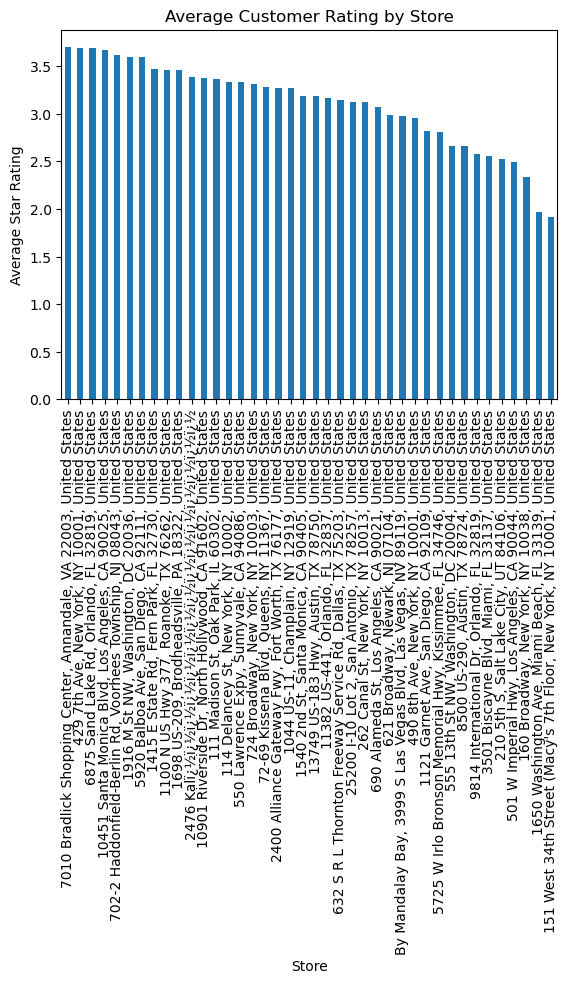

In [ ]:
# will give averag rating per store... this will add up 
# How it calculates average .. add up al the ratigns and divide by number of ratings...
# thsi does tn take account of number of ratsing per store....
store_summary = (mcd_time_rating_add_df.groupby("store_address").agg(avg_rating=("star_rating_num", "mean"), review_count=("review", "count")))

# Sort by average rating
store_summary_sorted = store_summary.sort_values("avg_rating", ascending=False)

# Plot average rating per store
plt.figure()
store_summary_sorted["avg_rating"].plot(kind="bar")
plt.xlabel("Store")
plt.ylabel("Average Star Rating")
plt.title("Average Customer Rating by Store")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [78]:
# total number of stores
mcd_time_rating_add_df["store_address"].nunique()

40

In [79]:
# Create store ID to act as unique Identifier

# Create store_id using factorization
mcd_time_rating_add_df["store_id"] = (mcd_time_rating_add_df["store_address"].astype("category").cat.codes)


In [80]:
# quick look at data to see if its clean, no duplicates, null values unusual characters etc
# convert it to d first so can easily run some checks over it
# mcd_df=pd.DataFrame(processed_per_file_data)
# view various dataframe details
# checking for null values and specific unknown values
print ("Rows     : " , mcd_time_rating_add_df.shape[0])
print ("Columns  : " , mcd_time_rating_add_df.shape[1])
print('------')
print ("\nFeatures : \n" , mcd_time_rating_add_df.columns.tolist())
print('------')
print ("\nMissing values :  ", mcd_time_rating_add_df.isnull().sum().values.sum())
print('------')
print ("\nMissing values per column:  ", mcd_time_rating_add_df.isnull().sum())
print('------')
print('\nnum of dups in df   =   {}'.format(mcd_time_rating_add_df.duplicated().sum()))
print('------')
print ("\nUnique values :  \n", mcd_time_rating_add_df.nunique())
print('------')
print('\n null values = ', mcd_time_rating_add_df.isnull().values.any())
print('------')
mcd_time_rating_add_df_missing = (mcd_time_rating_add_df=='?').sum()
print('\"  ?   \" values present =  \n',mcd_time_rating_add_df_missing)
print('------')
mcd_time_rating_add_df_unknown = (mcd_df=='unknown').sum()
print('\"   unknown   \" values present =  \n',mcd_time_rating_add_df_unknown)
print('------')
mcd_time_rating_add_df_na = mcd_df.isin(['N/A', 'N\\A', 'NA', 'n/a', 'n\\A', 'na', 'N_A']).sum()
print('    NA     values present = \n', mcd_time_rating_add_df_na)
print('------')
mcd_time_rating_add_df_none = mcd_df.isin(['None', 'none']).sum()
print('    none    values present = \n', mcd_time_rating_add_df_none)

Rows     :  33396
Columns  :  19
------

Features : 
 ['reviewer_id', 'store_name', 'category', 'store_address', 'latitude ', 'longitude', 'rating_count', 'review_time', 'review', 'rating', 'review_relative_time', 'star_rating_num', 'street_number', 'street_name', 'city', 'state', 'zip_code', 'country', 'store_id']
------

Missing values :   4990
------

Missing values per column:   reviewer_id                0
store_name                 0
category                   0
store_address              0
latitude                 660
longitude                660
rating_count               0
review_time                0
review                     0
rating                     0
review_relative_time       0
star_rating_num            0
street_number           1030
street_name                0
city                     660
state                    660
zip_code                 660
country                  660
store_id                   0
dtype: int64
------

num of dups in df   =   0
------

Unique v

In [94]:
print(mcd_time_rating_add_df["street_number"].value_counts(dropna=False))


street_number
9814     1890
5725     1720
10901    1710
1415     1700
632      1650
3501     1570
621      1290
1100     1168
72-69    1140
429      1140
724      1140
None     1030
1698     1028
702-2     943
8500      926
210       890
490       870
2400      850
1540      820
13749     800
550       800
111       751
11382     710
1916      680
1121      680
2476      660
25200     635
1044      620
7010      602
1650      570
690       550
5920      550
6875      490
501       481
262       270
151        60
114         3
10451       3
555         3
160         3
Name: count, dtype: int64
